# importing of libraries 

In [1]:

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

# Load Dataset and perform EDA (Exploratory Data Analysis)

In [2]:

df = pd.read_csv(r'C:\Users\HP\Downloads\c107fa55-45be-4f9c-8f61-088e88d1fb0c (2).csv')

# View five first rows

In [3]:

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


# View the columns

In [4]:

df.columns

Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='str')

# rows and columns number

In [5]:

df.shape

(572, 5)

# Missing values per column

In [6]:

df.isnull().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

# dtypes and non-null columns

In [7]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    str    
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    str    
 4   Sales         572 non-null    float64
dtypes: float64(3), str(2)
memory usage: 22.5 KB


In [8]:
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


# convertining the strings to int values

In [9]:
 
df = pd.get_dummies(df, columns=['TV', 'Influencer'],
    drop_first=True,dtype=int)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Radio             572 non-null    float64
 1   Social Media      572 non-null    float64
 2   Sales             572 non-null    float64
 3   TV_Low            572 non-null    int64  
 4   TV_Medium         572 non-null    int64  
 5   Influencer_Mega   572 non-null    int64  
 6   Influencer_Micro  572 non-null    int64  
 7   Influencer_Nano   572 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 35.9 KB


In [11]:
print(df)

         Radio  Social Media       Sales  TV_Low  TV_Medium  Influencer_Mega  \
0     3.518070      2.293790   55.261284       1          0                0   
1     7.756876      2.572287   67.574904       1          0                1   
2    20.348988      1.227180  272.250108       0          0                0   
3    20.108487      2.728374  195.102176       0          1                1   
4    31.653200      7.776978  273.960377       0          0                0   
..         ...           ...         ...     ...        ...              ...   
567  14.656633      3.817980  191.521266       0          1                0   
568  28.110171      7.358169  297.626731       0          0                1   
569  11.401084      5.818697  145.416851       0          1                0   
570  21.119991      5.703028  209.326830       0          1                0   
571  13.221237      3.660566  135.773151       1          0                0   

     Influencer_Micro  Influencer_Nano 

# Check for multicollinearity among independent variables (X) using correlation matrices and VIF
# Correlation Matrix

In [12]:

corr_matrix = df[['TV_Low', 'TV_Medium', 'Influencer_Mega', 'Radio', 'Social Media', 'Sales', 'Influencer_Micro',
                  'Influencer_Nano']].corr()

print(corr_matrix)

                    TV_Low  TV_Medium  Influencer_Mega     Radio  \
TV_Low            1.000000  -0.550117        -0.052697 -0.674203   
TV_Medium        -0.550117   1.000000         0.067488  0.004400   
Influencer_Mega  -0.052697   0.067488         1.000000  0.035704   
Radio            -0.674203   0.004400         0.035704  1.000000   
Social Media     -0.423910  -0.008272         0.066023  0.629941   
Sales            -0.805896   0.050449         0.032443  0.858036   
Influencer_Micro  0.016107   0.007302        -0.336096  0.001712   
Influencer_Nano   0.006815  -0.059374        -0.345177  0.015640   

                  Social Media     Sales  Influencer_Micro  Influencer_Nano  
TV_Low               -0.423910 -0.805896          0.016107         0.006815  
TV_Medium            -0.008272  0.050449          0.007302        -0.059374  
Influencer_Mega       0.066023  0.032443         -0.336096        -0.345177  
Radio                 0.629941  0.858036          0.001712         0.015640

# Visualization of corr_matrix

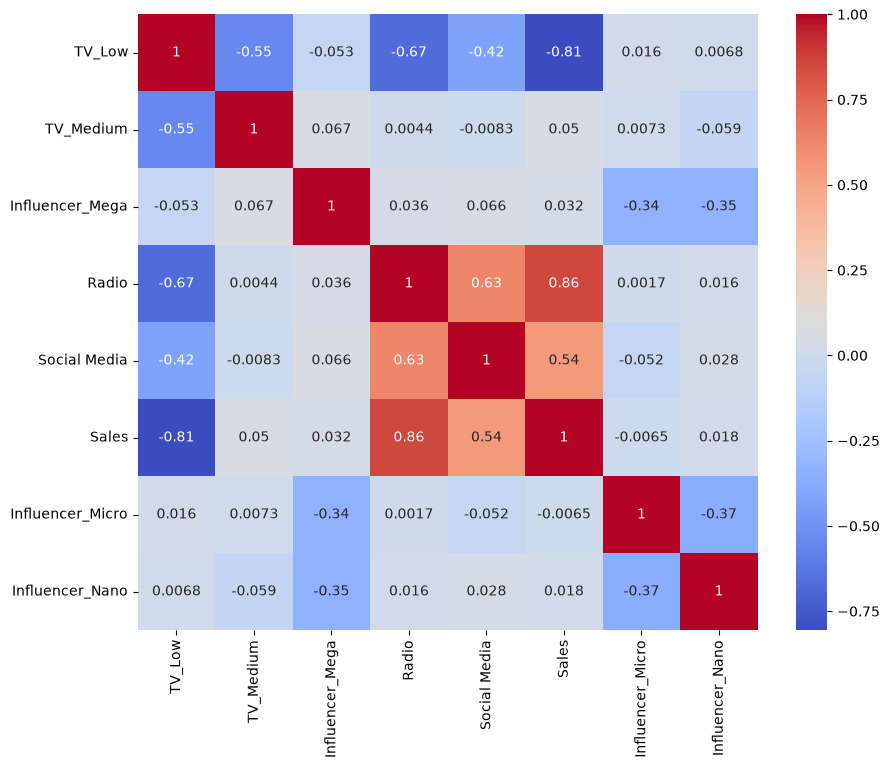

In [13]:

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

plt.show()

# VIF (Variance Inflation Factor)

In [14]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [15]:
X = df[['TV_Low', 'TV_Medium', 'Influencer_Mega', 'Radio', 'Social Media', 'Influencer_Micro',
                  'Influencer_Nano']]

In [16]:
X = df.drop('Sales', axis=1)

Y = df['Sales']

In [17]:
print(X.head())

       Radio  Social Media  TV_Low  TV_Medium  Influencer_Mega  \
0   3.518070      2.293790       1          0                0   
1   7.756876      2.572287       1          0                1   
2  20.348988      1.227180       0          0                0   
3  20.108487      2.728374       0          1                1   
4  31.653200      7.776978       0          0                0   

   Influencer_Micro  Influencer_Nano  
0                 1                0  
1                 0                0  
2                 1                0  
3                 0                0  
4                 0                1  


In [18]:
print(Y.head())

0     55.261284
1     67.574904
2    272.250108
3    195.102176
4    273.960377
Name: Sales, dtype: float64


# Calculate VIF for each column
# Interpretation
# VIF	Meaning
# 1–5	Acceptable
# 5–10	Moderate concern
# >10	Serious multicollinearity

In [19]:

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values('VIF', ascending=False))

            Feature       VIF
0             Radio  6.695980
1      Social Media  5.344600
6   Influencer_Nano  2.084801
5  Influencer_Micro  2.083851
4   Influencer_Mega  1.996014
3         TV_Medium  1.664554
2            TV_Low  1.661129


# Building Multiple Linear Regression Model

In [20]:

import statsmodels.api as sm
X = sm.add_constant(X)

# 1. Make sure X is numeric + has constant

In [21]:

X = X.astype(float)
X = sm.add_constant(X)

In [22]:
model = sm.OLS(Y, X).fit()

# Evaluate Model Performance

In [23]:

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Sat, 27 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        12:21:12   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

# Approximately 90.4% of the variation in sales is explained by advertising expenditure and influencer category variables, indicating a strong predictive model.
# The Adjusted R² value of 0.903 indicates that approximately 90.3% of the variability in sales is explained by the independent variables after accounting for model complexity, demonstrating excellent model performance
# The regression model as a whole is statistically significant.
# The overall regression model was statistically significant (F = 760.4, p < 0.001), indicating that at least one predictor variable significantly contributes to explaining sales performance


# Diagnostic Plots
# Linearity

<Axes: >

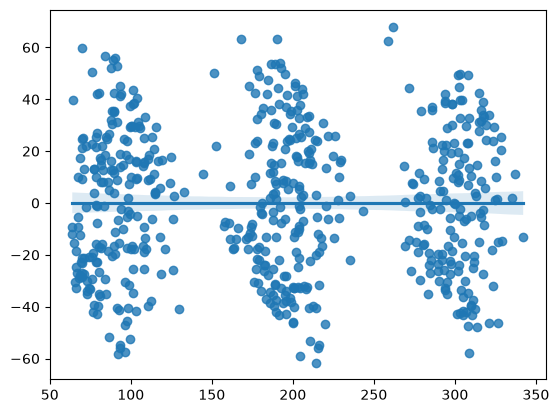

In [24]:

sns.regplot(x=model.fittedvalues,
            y=model.resid)


# Normality

<Axes: ylabel='Count'>

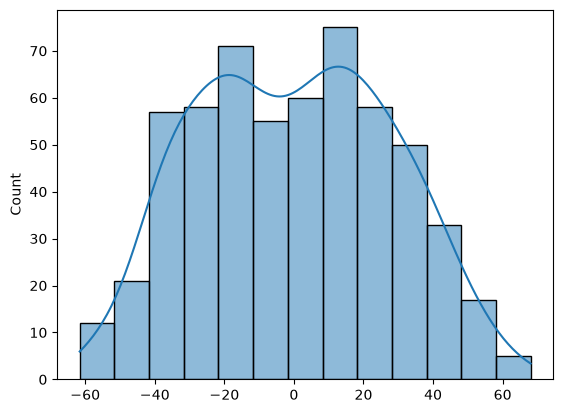

In [25]:

sns.histplot(model.resid, kde=True)

# Homoscedasticity

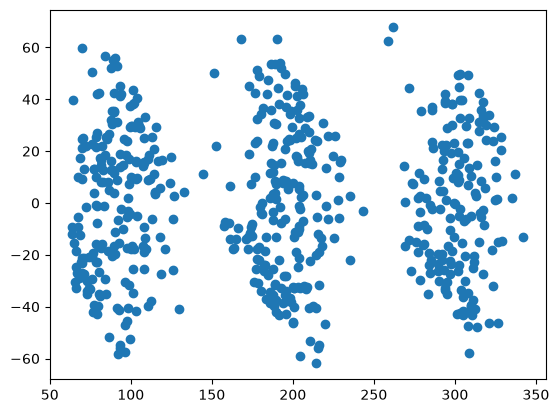

In [26]:
plt.scatter(model.fittedvalues,
            model.resid)

# Business Recommendation using the coef and p-value
# The regression model explained approximately 90.3% of the variation in sales and was statistically significant overall. TV advertising emerged as the most influential marketing channel, with high TV expenditure producing substantially greater sales than medium or low expenditure levels. Radio advertising also demonstrated a significant positive effect on sales. In contrast, Social Media expenditure and influencer categories did not significantly contribute to sales performance. Therefore, marketing resources should be prioritized toward TV advertising, supported by strategic Radio investments, while Social Media and influencer marketing expenditures should be reviewed and optimized to improve return on investment.
